# Emotion Classification of UFC/MMA Tweets (v2)
## Focal Loss + SHAP/LIME Explainability

This notebook implements:
1. Data loading and stratified train/val/test splits (96,491 tweets)
2. Dataset exploration: class distribution, tweet length, word clouds, yearly distribution
3. TF-IDF baseline models (Logistic Regression, SVM, Naive Bayes)
4. Fine-tuned BERT (bert-base-uncased) with focal loss and frozen encoder
5. Fine-tuned RoBERTa (roberta-base) with focal loss and frozen encoder
6. Results comparison, confusion matrices, per-class F1
7. SHAP/LIME explainability analysis
8. Enhanced error analysis with linguistic discussion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## 1. Data Loading & Preparation

In [2]:
df = pd.read_csv('processed_data_v2/tweets_labeled.csv')
print(f'Dataset size: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["source_date"].min()} to {df["source_date"].max()}')
df.head()

Dataset size: 96491
Columns: ['text', 'source_date', 'emotion']
Date range: 2020-01-01 to 2025-12-31


,text,source_date,emotion
0,"I would type out a whole ""Happy New Years, thi...",2020-01-01,joy
1,It's absolutely disgusting to see the effects ...,2020-01-01,disgust
2,Conor McGregor's head coach promises 'this is ...,2020-01-01,neutral
3,"Undefeated as a pro, is intent on earning his ...",2020-01-01,neutral
4,Close out 2019 profiting on 9 of the past 11 e...,2020-01-01,neutral


In [3]:
# Encode emotion labels to integers
emotion_labels = sorted(df['emotion'].unique())
label2id = {label: idx for idx, label in enumerate(emotion_labels)}
id2label = {idx: label for label, idx in label2id.items()}

df['label'] = df['emotion'].map(label2id)

print('Label mapping:')
for label, idx in sorted(label2id.items(), key=lambda x: x[1]):
    count = (df['label'] == idx).sum()
    pct = count / len(df) * 100
    print(f'  {idx}: {label} ({count:,} samples, {pct:.1f}%)')

Label mapping:
  0: anger (7,988 samples, 8.3%)
  1: disgust (4,129 samples, 4.3%)
  2: fear (3,223 samples, 3.3%)
  3: joy (11,465 samples, 11.9%)
  4: neutral (55,225 samples, 57.2%)
  5: sadness (5,970 samples, 6.2%)
  6: surprise (8,491 samples, 8.8%)


## 2. Dataset Exploration & Figures

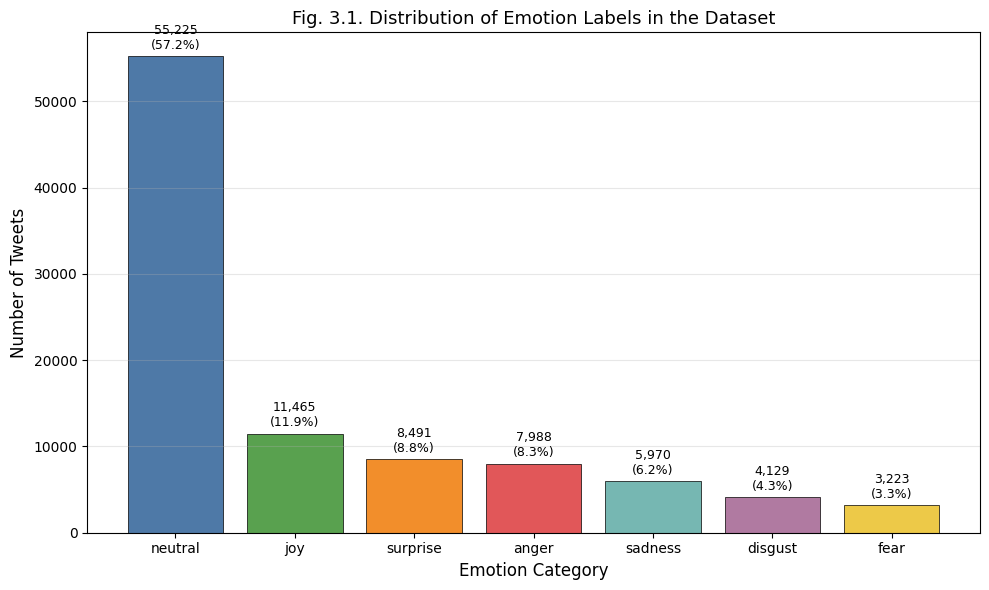

In [4]:
# Fig 3.1: Class distribution bar chart
emotion_order = ['neutral', 'joy', 'surprise', 'anger', 'sadness', 'disgust', 'fear']
emotion_counts = df['emotion'].value_counts().reindex(emotion_order)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759', '#76b7b2', '#b07aa1', '#edc948']
bars = ax.bar(emotion_order, emotion_counts.values, color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, emotion_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Emotion Category', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Fig. 3.1. Distribution of Emotion Labels in the Dataset', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_3_1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

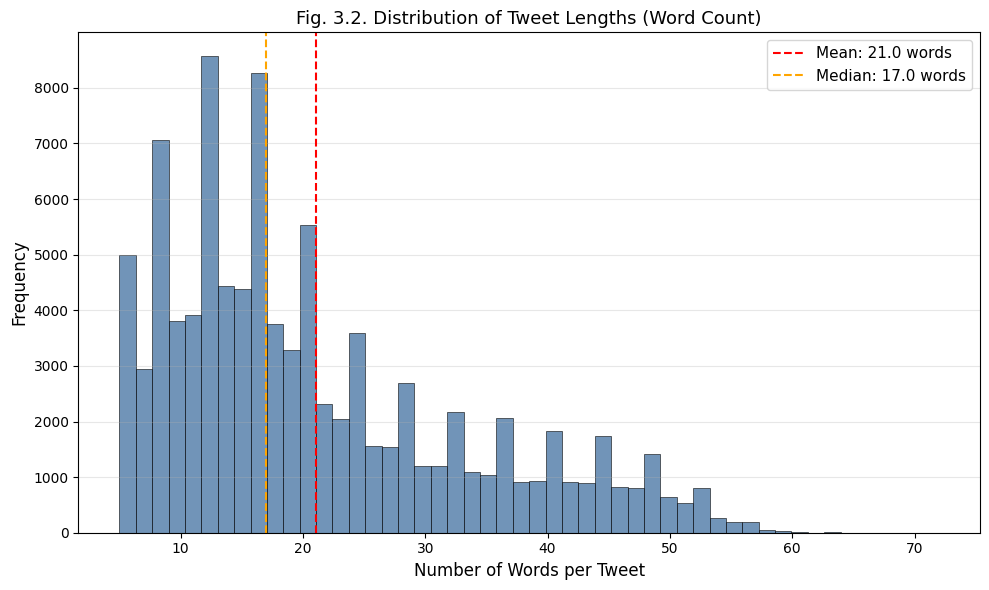

Word count statistics:
  Mean:   21.0
  Median: 17.0
  Std:    12.3
  Min:    5
  Max:    72


In [5]:
# Fig 3.2: Tweet length distribution histogram (word count)
df['word_count'] = df['text'].str.split().str.len()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df['word_count'], bins=50, color='#4e79a7', edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(df['word_count'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {df["word_count"].mean():.1f} words')
ax.axvline(df['word_count'].median(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Median: {df["word_count"].median():.1f} words')

ax.set_xlabel('Number of Words per Tweet', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Fig. 3.2. Distribution of Tweet Lengths (Word Count)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_3_2_tweet_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Word count statistics:')
print(f'  Mean:   {df["word_count"].mean():.1f}')
print(f'  Median: {df["word_count"].median():.1f}')
print(f'  Std:    {df["word_count"].std():.1f}')
print(f'  Min:    {df["word_count"].min()}')
print(f'  Max:    {df["word_count"].max()}')

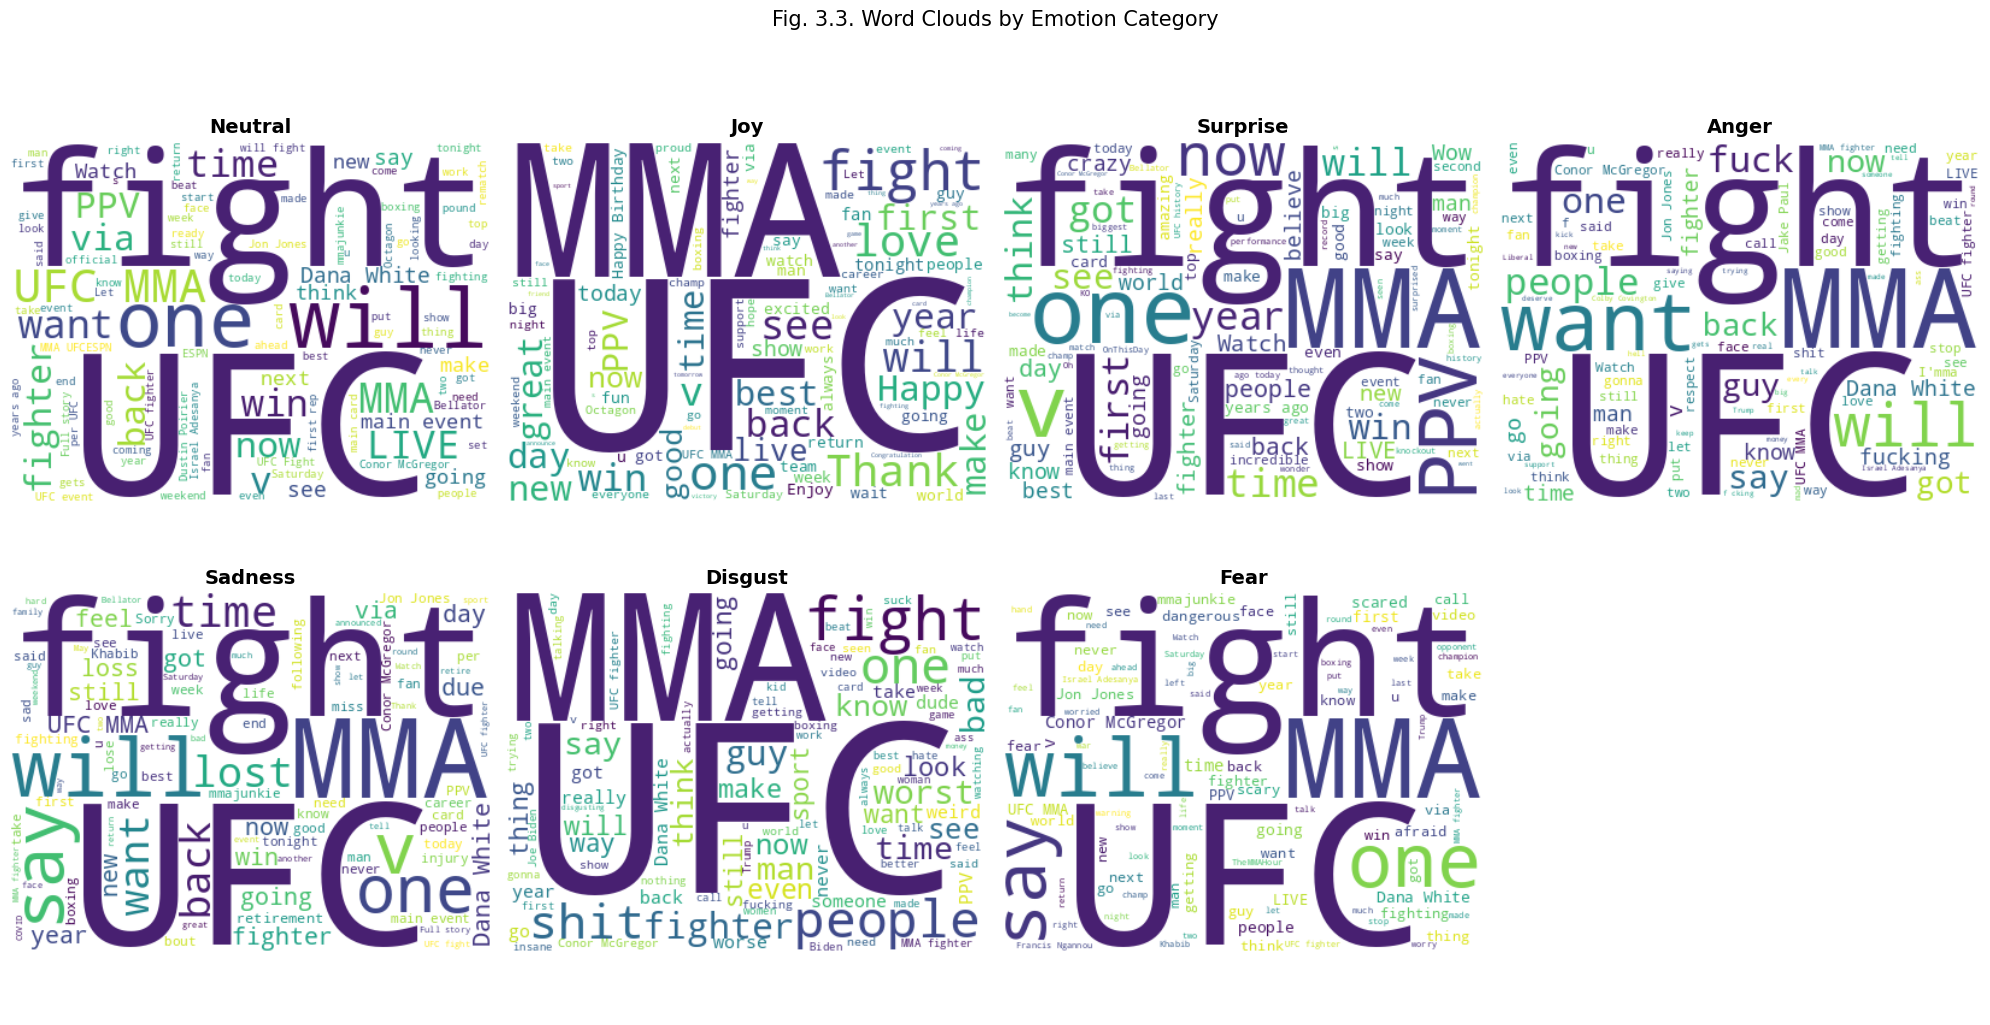

In [6]:
# Fig 3.3: Word clouds per emotion
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, emotion in enumerate(emotion_order):
    text = ' '.join(df[df['emotion'] == emotion]['text'].values)
    wc = WordCloud(width=400, height=300, background_color='white',
                   max_words=100, colormap='viridis', random_state=SEED)
    wc.generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(emotion.capitalize(), fontsize=14, fontweight='bold')
    axes[i].axis('off')

# Hide the 8th subplot (we have 7 emotions)
axes[7].axis('off')

fig.suptitle('Fig. 3.3. Word Clouds by Emotion Category', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('fig_3_3_word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

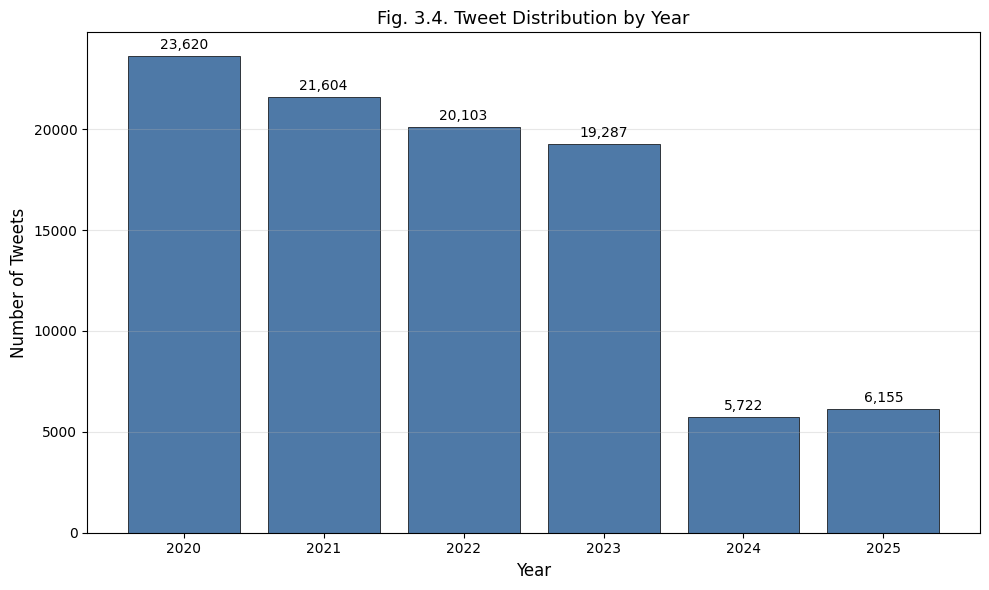

Year distribution:
  2020: 23,620 tweets
  2021: 21,604 tweets
  2022: 20,103 tweets
  2023: 19,287 tweets
  2024: 5,722 tweets
  2025: 6,155 tweets


In [7]:
# Fig 3.4: Year-by-year tweet distribution
df['year'] = df['source_date'].str[:4]
year_counts = df['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(year_counts.index, year_counts.values, color='#4e79a7',
              edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, year_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{count:,}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Fig. 3.4. Tweet Distribution by Year', fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_3_4_yearly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Year distribution:')
for year, count in year_counts.items():
    print(f'  {year}: {count:,} tweets')

In [8]:
# Stratified train/validation/test split (70/15/15)
texts = df['text'].values
labels = df['label'].values

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.30, random_state=SEED, stratify=labels
)

# Second split: 50/50 of temp -> 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f'Train: {len(X_train):,} samples')
print(f'Val:   {len(X_val):,} samples')
print(f'Test:  {len(X_test):,} samples')

# Class distribution per split
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    dist = pd.Series(y).value_counts().sort_index()
    print(f'\n{name} distribution:')
    for idx, count in dist.items():
        print(f'  {id2label[idx]}: {count:,} ({count/len(y)*100:.1f}%)')

Train: 67,543 samples
Val:   14,474 samples
Test:  14,474 samples

Train distribution:
  anger: 5,592 (8.3%)
  disgust: 2,890 (4.3%)
  fear: 2,256 (3.3%)
  joy: 8,025 (11.9%)
  neutral: 38,657 (57.2%)
  sadness: 4,179 (6.2%)
  surprise: 5,944 (8.8%)

Val distribution:
  anger: 1,198 (8.3%)
  disgust: 619 (4.3%)
  fear: 484 (3.3%)
  joy: 1,720 (11.9%)
  neutral: 8,284 (57.2%)
  sadness: 895 (6.2%)
  surprise: 1,274 (8.8%)

Test distribution:
  anger: 1,198 (8.3%)
  disgust: 620 (4.3%)
  fear: 483 (3.3%)
  joy: 1,720 (11.9%)
  neutral: 8,284 (57.2%)
  sadness: 896 (6.2%)
  surprise: 1,273 (8.8%)


## 3. Baseline Models (TF-IDF + Classical ML)

In [9]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_):,}')
print(f'Feature matrix shape: {X_train_tfidf.shape}')

TF-IDF vocabulary size: 10,000
Feature matrix shape: (67543, 10000)


In [10]:
# Train and evaluate baseline classifiers
results = {}

classifiers = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'
    ),
    'SVM (LinearSVC)': LinearSVC(
        max_iter=2000, random_state=SEED, class_weight='balanced'
    ),
    'Naive Bayes': MultinomialNB()
}

baseline_preds = {}

for name, clf in classifiers.items():
    print(f'\n{"="*60}')
    print(f'Training: {name}')
    print(f'{"="*60}')
    
    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)
    baseline_preds[name] = y_pred
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    macro_recall = recall_score(y_test, y_pred, average='macro')
    
    results[name] = {
        'Accuracy': acc,
        'Macro F1': macro_f1,
        'Macro Recall': macro_recall
    }
    
    print(f'Accuracy:     {acc:.4f}')
    print(f'Macro F1:     {macro_f1:.4f}')
    print(f'Macro Recall: {macro_recall:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=emotion_labels))


Training: Logistic Regression


Accuracy:     0.5499
Macro F1:     0.4643
Macro Recall: 0.5501

Classification Report:
              precision    recall  f1-score   support

       anger       0.37      0.48      0.41      1198
     disgust       0.29      0.57      0.39       620
        fear       0.23      0.46      0.31       483
         joy       0.52      0.65      0.58      1720
     neutral       0.85      0.54      0.66      8284
     sadness       0.37      0.59      0.46       896
    surprise       0.37      0.56      0.44      1273

    accuracy                           0.55     14474
   macro avg       0.43      0.55      0.46     14474
weighted avg       0.65      0.55      0.57     14474


Training: SVM (LinearSVC)


Accuracy:     0.6183
Macro F1:     0.4853
Macro Recall: 0.5154

Classification Report:
              precision    recall  f1-score   support

       anger       0.42      0.46      0.44      1198
     disgust       0.33      0.47      0.39       620
        fear       0.30      0.40      0.34       483
         joy       0.56      0.59      0.57      1720
     neutral       0.80      0.71      0.75      8284
     sadness       0.42      0.52      0.46       896
    surprise       0.42      0.47      0.45      1273

    accuracy                           0.62     14474
   macro avg       0.46      0.52      0.49     14474
weighted avg       0.65      0.62      0.63     14474


Training: Naive Bayes
Accuracy:     0.6280
Macro F1:     0.2860
Macro Recall: 0.2538

Classification Report:
              precision    recall  f1-score   support

       anger       0.48      0.21      0.29      1198
     disgust       0.60      0.09      0.16       620
        fear       1.00      0.02      0.03

## 4. Focal Loss Implementation

In [11]:
class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.
    
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    Lin et al., "Focal Loss for Dense Object Detection", ICCV 2017.
    
    Parameters:
        alpha: class weights (tensor of shape [num_classes])
        gamma: focusing parameter (default=0.5)
            - gamma=0 reduces to standard weighted cross-entropy
            - higher gamma focuses more on hard, misclassified examples
    """
    def __init__(self, alpha=None, gamma=0.5, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits, targets, weight=self.alpha, reduction='none'
        )
        pt = torch.exp(-ce_loss)  # probability of correct class
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

print('FocalLoss class defined.')
print('Formula: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)')
print('gamma=0.5: gentle focusing on hard examples while preserving stable gradients')

FocalLoss class defined.
Formula: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
gamma=0.5: gentle focusing on hard examples while preserving stable gradients


## 5. Transformer Training Infrastructure

In [12]:
# PyTorch Dataset for transformer models
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [13]:
def train_transformer(model_name, X_train, y_train, X_val, y_val, X_test, y_test,
                      num_labels=7, epochs=10, batch_size=32, lr=2e-5, gamma=0.5):
    """Train a transformer model with frozen base encoder (except last 2 layers),
    replaced classification head, and focal loss."""
    
    print(f'Loading {model_name}...')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=num_labels
    )
    
    # Freeze all base encoder parameters first
    base_model = None
    if hasattr(model, 'bert'):
        base_model = model.bert
    elif hasattr(model, 'roberta'):
        base_model = model.roberta
    elif hasattr(model, 'distilbert'):
        base_model = model.distilbert
    
    if base_model is not None:
        # Freeze everything first
        for param in base_model.parameters():
            param.requires_grad = False
        
        # Unfreeze last 2 encoder layers
        encoder_layers = base_model.encoder.layer
        num_layers = len(encoder_layers)
        for i in range(max(0, num_layers - 2), num_layers):
            for param in encoder_layers[i].parameters():
                param.requires_grad = True
            print(f'  Unfroze encoder layer {i}')
        
        # Unfreeze pooler if it exists (BERT has pooler, RoBERTa does not by default)
        if hasattr(base_model, 'pooler') and base_model.pooler is not None:
            for param in base_model.pooler.parameters():
                param.requires_grad = True
            print('  Unfroze pooler layer')
    
    # Replace classification head with a new one
    if hasattr(model, 'classifier'):
        if isinstance(model.classifier, nn.Linear):
            in_features = model.classifier.in_features
            model.classifier = nn.Linear(in_features, num_labels)
        elif isinstance(model.classifier, nn.Module):
            if hasattr(model.classifier, 'out_proj'):
                in_features = model.classifier.out_proj.in_features
                model.classifier.out_proj = nn.Linear(in_features, num_labels)
    
    # Count trainable parameters
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f'Trainable parameters: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)')
    
    model = model.to(device)
    
    # Create datasets and dataloaders
    train_dataset = TweetDataset(X_train, y_train, tokenizer)
    val_dataset = TweetDataset(X_val, y_val, tokenizer)
    test_dataset = TweetDataset(X_test, y_test, tokenizer)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Compute class weights for imbalanced dataset
    class_weights = compute_class_weight('balanced', classes=np.arange(num_labels), y=y_train)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    print(f'Class weights: {dict(zip(emotion_labels, class_weights.round(2)))}')
    
    # Focal Loss with class weights
    loss_fn = FocalLoss(alpha=class_weights_tensor, gamma=gamma)
    print(f'Using Focal Loss with gamma={gamma}')
    
    # Optimizer
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    
    # Training loop
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
            if (batch_idx + 1) % 200 == 0:
                print(f'  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | '
                      f'Loss: {loss.item():.4f}')
        
        avg_loss = total_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_preds, val_true = [], []
        val_total_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                batch_labels = batch['label'].to(device)
                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                val_total_loss += loss_fn(outputs.logits, batch_labels).item()
                preds = outputs.logits.argmax(dim=-1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(batch['label'].numpy())
        
        avg_val_loss = val_total_loss / len(val_loader)
        val_acc = accuracy_score(val_true, val_preds)
        val_f1 = f1_score(val_true, val_preds, average='macro')
        
        history['train_loss'].append(avg_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | '
              f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | '
              f'Val Macro F1: {val_f1:.4f}')
    
    # Final test evaluation
    model.eval()
    test_preds, test_true = [], []
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            test_preds.extend(preds)
            test_true.extend(batch['label'].numpy())
    
    test_acc = accuracy_score(test_true, test_preds)
    test_f1 = f1_score(test_true, test_preds, average='macro')
    test_recall = recall_score(test_true, test_preds, average='macro')
    
    return {
        'model': model,
        'tokenizer': tokenizer,
        'history': history,
        'test_preds': np.array(test_preds),
        'test_true': np.array(test_true),
        'metrics': {
            'Accuracy': test_acc,
            'Macro F1': test_f1,
            'Macro Recall': test_recall
        }
    }

## 6. Train BERT

In [14]:
print('='*60)
print('Training BERT (bert-base-uncased) with Focal Loss')
print('='*60)

bert_result = train_transformer(
    'bert-base-uncased',
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=10, batch_size=32, lr=2e-5, gamma=0.5
)

results['BERT'] = bert_result['metrics']

print(f'\nTest Results:')
print(f'Accuracy:     {bert_result["metrics"]["Accuracy"]:.4f}')
print(f'Macro F1:     {bert_result["metrics"]["Macro F1"]:.4f}')
print(f'Macro Recall: {bert_result["metrics"]["Macro Recall"]:.4f}')
print(f'\nClassification Report:')
print(classification_report(bert_result['test_true'], bert_result['test_preds'],
                            target_names=emotion_labels))

Training BERT (bert-base-uncased) with Focal Loss
Loading bert-base-uncased...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Unfroze encoder layer 10
  Unfroze encoder layer 11
  Unfroze pooler layer
Trainable parameters: 14,771,719 / 109,487,623 (13.5%)


Class weights: {'anger': np.float64(1.73), 'disgust': np.float64(3.34), 'fear': np.float64(4.28), 'joy': np.float64(1.2), 'neutral': np.float64(0.25), 'sadness': np.float64(2.31), 'surprise': np.float64(1.62)}
Using Focal Loss with gamma=0.5


...

  Epoch 10 | Batch 1600/2111 | Loss: 0.2179


  Epoch 10 | Batch 1800/2111 | Loss: 0.3026


  Epoch 10 | Batch 2000/2111 | Loss: 0.5413


Epoch 10/10 | Train Loss: 0.3203 | Val Loss: 0.9456 | Val Acc: 0.6141 | Val Macro F1: 0.5722



Test Results:
Accuracy:     0.6064
Macro F1:     0.5686
Macro Recall: 0.6859

Classification Report:
              precision    recall  f1-score   support

       anger       0.46      0.71      0.56      1198
     disgust       0.50      0.57      0.53       620
        fear       0.39      0.65      0.49       483
         joy       0.50      0.80      0.62      1720
     neutral       0.94      0.51      0.66      8284
     sadness       0.49      0.79      0.60       896
    surprise       0.40      0.78      0.53      1273

    accuracy                           0.61     14474
   macro avg       0.53      0.69      0.57     14474
weighted avg       0.74      0.61      0.62     14474



## 7. Train RoBERTa

In [15]:
print('='*60)
print('Training RoBERTa (roberta-base) with Focal Loss')
print('='*60)

roberta_result = train_transformer(
    'roberta-base',
    X_train, y_train, X_val, y_val, X_test, y_test,
    epochs=10, batch_size=32, lr=2e-5, gamma=0.5
)

results['RoBERTa'] = roberta_result['metrics']

print(f'\nTest Results:')
print(f'Accuracy:     {roberta_result["metrics"]["Accuracy"]:.4f}')
print(f'Macro F1:     {roberta_result["metrics"]["Macro F1"]:.4f}')
print(f'Macro Recall: {roberta_result["metrics"]["Macro Recall"]:.4f}')
print(f'\nClassification Report:')
print(classification_report(roberta_result['test_true'], roberta_result['test_preds'],
                            target_names=emotion_labels))

Training RoBERTa (roberta-base) with Focal Loss
Loading roberta-base...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

  Epoch 10 | Batch 1600/2111 | Loss: 0.1252


  Epoch 10 | Batch 1800/2111 | Loss: 0.3927


  Epoch 10 | Batch 2000/2111 | Loss: 0.2164


Epoch 10/10 | Train Loss: 0.3157 | Val Loss: 0.7424 | Val Acc: 0.6622 | Val Macro F1: 0.6106



Test Results:
Accuracy:     0.6664
Macro F1:     0.6200
Macro Recall: 0.7417

Classification Report:
              precision    recall  f1-score   support

       anger       0.52      0.76      0.62      1198
     disgust       0.45      0.72      0.55       620
        fear       0.41      0.74      0.53       483
         joy       0.58      0.82      0.68      1720
     neutral       0.95      0.58      0.72      8284
     sadness       0.54      0.80      0.64       896
    surprise       0.48      0.77      0.59      1273

    accuracy                           0.67     14474
   macro avg       0.56      0.74      0.62     14474
weighted avg       0.76      0.67      0.68     14474



## 8. Results Comparison & Visualization

In [16]:
# Summary table
results_df = pd.DataFrame(results).T
results_df = results_df[['Accuracy', 'Macro F1', 'Macro Recall']]
results_df = results_df.round(4)
print('\n' + '='*60)
print('MODEL COMPARISON (Table 5.1)')
print('='*60)
print(results_df.to_string())

# Find best model
best_model_name = results_df['Macro F1'].idxmax()
print(f'\nBest model by Macro F1: {best_model_name}')
print(f'\nRelative improvement over best baseline (SVM):')
svm_f1 = results_df.loc['SVM (LinearSVC)', 'Macro F1']
best_f1 = results_df.loc[best_model_name, 'Macro F1']
print(f'  {svm_f1:.4f} -> {best_f1:.4f} ({(best_f1 - svm_f1) / svm_f1 * 100:.1f}% relative improvement)')


MODEL COMPARISON (Table 5.1)
                     Accuracy  Macro F1  Macro Recall
Logistic Regression    0.5499    0.4643        0.5501
SVM (LinearSVC)        0.6183    0.4853        0.5154
Naive Bayes            0.6280    0.2860        0.2538
BERT                   0.6064    0.5686        0.6859
RoBERTa                0.6664    0.6200        0.7417

Best model by Macro F1: RoBERTa

Relative improvement over best baseline (SVM):
  0.4853 -> 0.6200 (27.8% relative improvement)


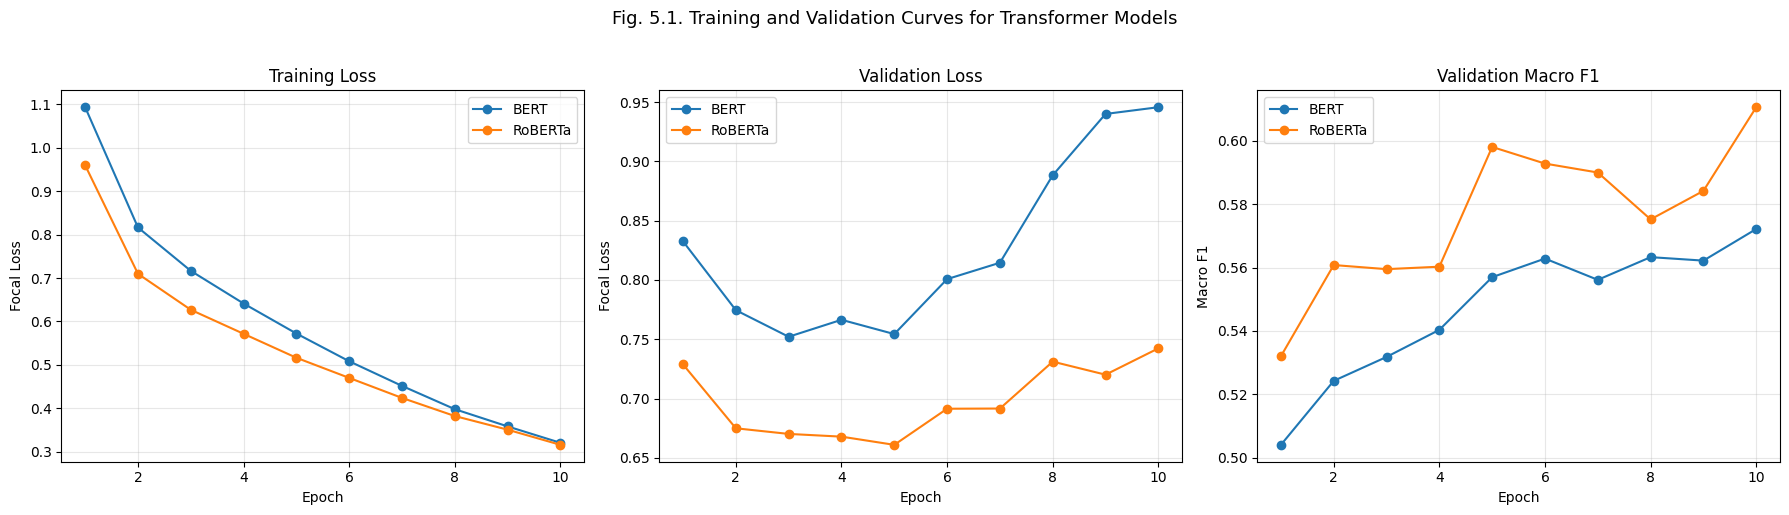

In [17]:
# Fig 5.1: Training curves (loss + validation F1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for name, result in [('BERT', bert_result), ('RoBERTa', roberta_result)]:
    epochs_range = range(1, len(result['history']['train_loss']) + 1)
    axes[0].plot(epochs_range, result['history']['train_loss'], marker='o', label=name)
    axes[1].plot(epochs_range, result['history']['val_loss'], marker='o', label=name)
    axes[2].plot(epochs_range, result['history']['val_f1'], marker='o', label=name)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Focal Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_title('Validation Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Macro F1')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.suptitle('Fig. 5.1. Training and Validation Curves for Transformer Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_5_1_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

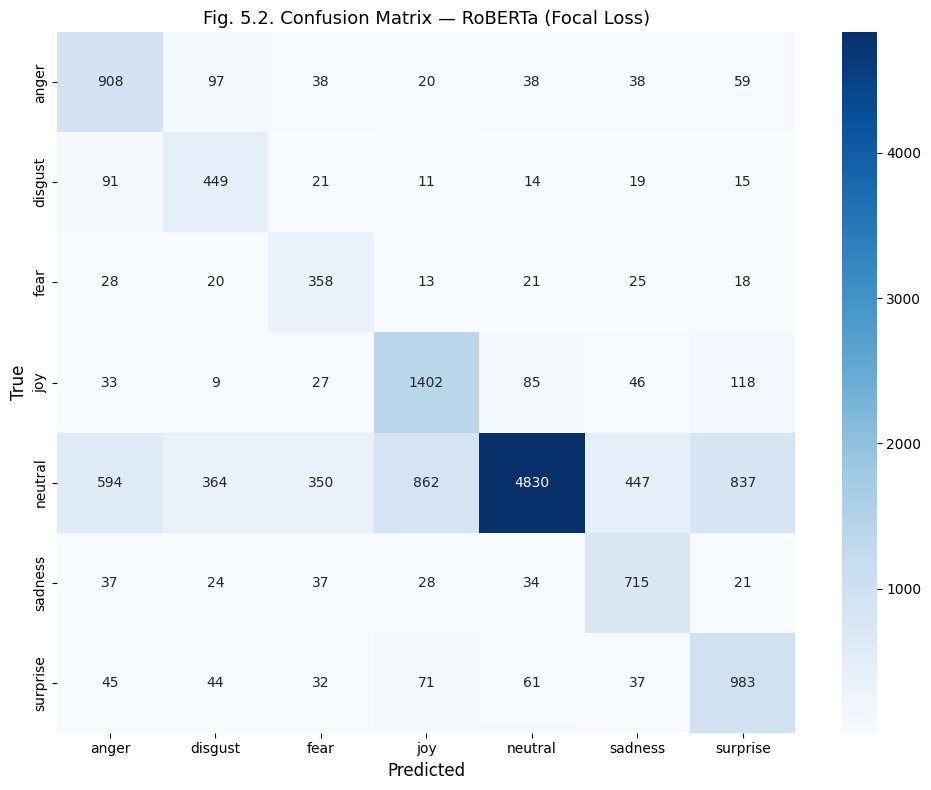

In [18]:
# Fig 5.2: Confusion matrix for best model (RoBERTa expected)
if best_model_name == 'BERT':
    best_preds = bert_result['test_preds']
    best_true = bert_result['test_true']
elif best_model_name == 'RoBERTa':
    best_preds = roberta_result['test_preds']
    best_true = roberta_result['test_true']
else:
    best_clf = classifiers[best_model_name]
    best_preds = best_clf.predict(X_test_tfidf)
    best_true = y_test

cm = confusion_matrix(best_true, best_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels, ax=ax)
ax.set_title(f'Fig. 5.2. Confusion Matrix — {best_model_name} (Focal Loss)', fontsize=13)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
plt.tight_layout()
plt.savefig('fig_5_2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

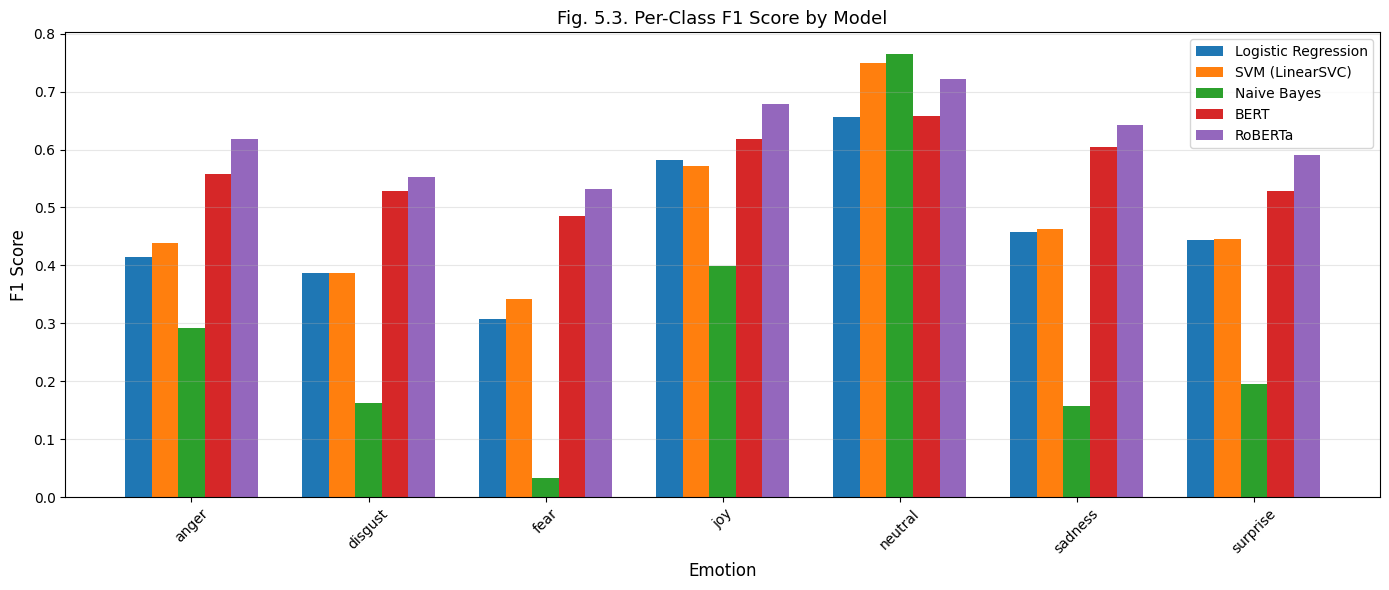


Per-class F1 scores:
          Logistic Regression  SVM (LinearSVC)  Naive Bayes    BERT  RoBERTa
anger                  0.4149           0.4388       0.2922  0.5573   0.6190
disgust                0.3869           0.3873       0.1620  0.5289   0.5519
fear                   0.3079           0.3413       0.0326  0.4850   0.5319
joy                    0.5819           0.5714       0.3998  0.6183   0.6794
neutral                0.6570           0.7497       0.7642  0.6579   0.7227
sadness                0.4571           0.4637       0.1567  0.6040   0.6433
surprise               0.4447           0.4451       0.1948  0.5287   0.5915


In [19]:
# Fig 5.3: Per-class F1 bar chart (all models)
per_class_f1 = {}

# Baseline models
for name in classifiers:
    per_class_f1[name] = f1_score(y_test, baseline_preds[name], average=None)

# Transformer models
per_class_f1['BERT'] = f1_score(bert_result['test_true'], bert_result['test_preds'], average=None)
per_class_f1['RoBERTa'] = f1_score(
    roberta_result['test_true'], roberta_result['test_preds'], average=None
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(emotion_labels))
width = 0.15
models = list(per_class_f1.keys())

for i, model_name in enumerate(models):
    offset = (i - len(models)/2 + 0.5) * width
    ax.bar(x + offset, per_class_f1[model_name], width, label=model_name)

ax.set_xlabel('Emotion', fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Fig. 5.3. Per-Class F1 Score by Model', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(emotion_labels, rotation=45)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('fig_5_3_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# Print per-class F1 table
print('\nPer-class F1 scores:')
f1_df = pd.DataFrame(per_class_f1, index=emotion_labels).round(4)
print(f1_df.to_string())

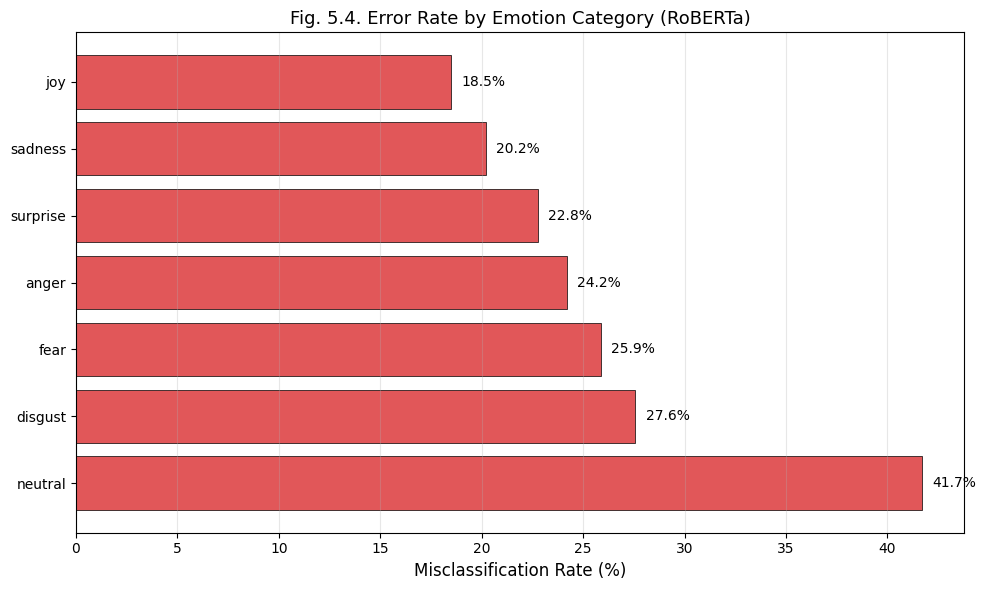

In [20]:
# Fig 5.4: Error distribution by emotion (misclassification rate per class)
misclassified = best_preds != best_true
error_rates = {}
for idx, emotion in id2label.items():
    mask = best_true == idx
    if mask.sum() > 0:
        error_rates[emotion] = misclassified[mask].sum() / mask.sum()

fig, ax = plt.subplots(figsize=(10, 6))
emotions_sorted = sorted(error_rates.keys(), key=lambda e: error_rates[e], reverse=True)
rates = [error_rates[e] * 100 for e in emotions_sorted]
bars = ax.barh(emotions_sorted, rates, color='#e15759', edgecolor='black', linewidth=0.5)

for bar, rate in zip(bars, rates):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{rate:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Misclassification Rate (%)', fontsize=12)
ax.set_title(f'Fig. 5.4. Error Rate by Emotion Category ({best_model_name})', fontsize=13)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('fig_5_4_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Error Analysis

In [21]:
# Analyze misclassifications from best model
misclassified_mask = best_preds != best_true
misclassified_indices = np.where(misclassified_mask)[0]

print(f'Total test samples: {len(best_true):,}')
print(f'Misclassified: {len(misclassified_indices):,} ({len(misclassified_indices)/len(best_true)*100:.1f}%)')

# Most common confusion pairs
confusion_pairs = {}
for idx in misclassified_indices:
    true_label = id2label[best_true[idx]]
    pred_label = id2label[best_preds[idx]]
    pair = f'{true_label} -> {pred_label}'
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

print(f'\nTop 15 confusion pairs:')
for pair, count in sorted(confusion_pairs.items(), key=lambda x: -x[1])[:15]:
    print(f'  {pair}: {count}')

Total test samples: 14,474
Misclassified: 4,829 (33.4%)

Top 15 confusion pairs:
  neutral -> joy: 862
  neutral -> surprise: 837
  neutral -> anger: 594
  neutral -> sadness: 447
  neutral -> disgust: 364
  neutral -> fear: 350
  joy -> surprise: 118
  anger -> disgust: 97
  disgust -> anger: 91
  joy -> neutral: 85
  surprise -> joy: 71
  surprise -> neutral: 61
  anger -> surprise: 59
  joy -> sadness: 46
  surprise -> anger: 45


In [22]:
# Detailed error analysis: sample misclassified tweets per confusion pair
print('\nDetailed Error Analysis: Sample Misclassified Tweets')
print('='*100)

# Focus on top confusion pairs
top_pairs = sorted(confusion_pairs.items(), key=lambda x: -x[1])[:6]

for pair_name, count in top_pairs:
    true_emotion, pred_emotion = pair_name.split(' -> ')
    true_id = label2id[true_emotion]
    pred_id = label2id[pred_emotion]
    
    # Find indices matching this confusion pair
    pair_indices = [i for i in misclassified_indices 
                    if best_true[i] == true_id and best_preds[i] == pred_id]
    
    print(f'\n--- {pair_name} ({count} instances) ---')
    np.random.seed(SEED)
    sample = np.random.choice(pair_indices, size=min(3, len(pair_indices)), replace=False)
    for idx in sample:
        text = X_test[idx][:200]
        print(f'  "{text}"')
    print()


Detailed Error Analysis: Sample Misclassified Tweets

--- neutral -> joy (862 instances) ---
  "Popcorn ready? Watch events along with some of the biggest stars - Only on ."
  "BTS 방탄소년단 2019 MMA 'Dionysus' Dance Practice 공개! ("
  "Exclusive backstage interview with STP after their match at Death Before Dishonor! Relive the action packed ROHDBD PPV anytime, anywhere, on any device! Visit ROHHONORCLUB.COM or download the ROH App "


--- neutral -> surprise (837 instances) ---
  "Record UFC PPV'S for both Conor McGregor vs Nate Diaz fights Is this the year for a Trilogy? UFC MMA"
  "China's biggest exports..... Plastic and Covid...."
  "ICYMI: vs. 3 is set for UFC252 on August 15. Who ya got? FULL DETAILS:"


--- neutral -> anger (594 instances) ---
  "Retired UFC vet Josh Thomson believes Cris Cyborg 'dismantles' Amanda Nunes in theoretical rematch ( )"
  "Called his shot and ready to blow the roof off in Boston Let's gooooooooooooo Ian Garry! Watch UFC292 LIVE from 1am on TNT Sports &

## 10. SHAP/LIME Explainability Analysis

In [23]:
from lime.lime_text import LimeTextExplainer

# Create a prediction function for LIME
# Use the best model (RoBERTa expected)
if best_model_name == 'RoBERTa':
    explain_model = roberta_result['model']
    explain_tokenizer = roberta_result['tokenizer']
elif best_model_name == 'BERT':
    explain_model = bert_result['model']
    explain_tokenizer = bert_result['tokenizer']
else:
    # Fallback to RoBERTa
    explain_model = roberta_result['model']
    explain_tokenizer = roberta_result['tokenizer']

explain_model.eval()

def predict_proba(texts):
    """Prediction function for LIME. Takes list of strings, returns probabilities."""
    all_probs = []
    batch_size = 16
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encodings = explain_tokenizer(
            batch_texts, truncation=True, padding='max_length',
            max_length=128, return_tensors='pt'
        )
        with torch.no_grad():
            outputs = explain_model(
                input_ids=encodings['input_ids'].to(device),
                attention_mask=encodings['attention_mask'].to(device)
            )
            probs = F.softmax(outputs.logits, dim=-1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)

explainer = LimeTextExplainer(class_names=emotion_labels, random_state=SEED)
print(f'LIME explainer initialized for {best_model_name}')
print(f'Class names: {emotion_labels}')

LIME explainer initialized for RoBERTa
Class names: ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']


In [24]:
# Select examples for LIME analysis:
# 1. Correctly classified tweets (one per emotion, where available)
# 2. Misclassified tweets from top confusion pairs

np.random.seed(SEED)
lime_examples = []

# Correctly classified: one per emotion
correct_mask = best_preds == best_true
for idx_label, emotion in id2label.items():
    candidates = np.where((best_true == idx_label) & correct_mask)[0]
    if len(candidates) > 0:
        chosen = np.random.choice(candidates)
        lime_examples.append({
            'idx': chosen, 'type': 'correct',
            'true': emotion, 'pred': emotion,
            'text': X_test[chosen]
        })

# Misclassified: top confusion pairs
for pair_name, count in top_pairs[:4]:
    true_emotion, pred_emotion = pair_name.split(' -> ')
    true_id = label2id[true_emotion]
    pred_id = label2id[pred_emotion]
    pair_indices = [i for i in misclassified_indices 
                    if best_true[i] == true_id and best_preds[i] == pred_id]
    if pair_indices:
        chosen = np.random.choice(pair_indices)
        lime_examples.append({
            'idx': chosen, 'type': 'misclassified',
            'true': true_emotion, 'pred': pred_emotion,
            'text': X_test[chosen]
        })

print(f'Selected {len(lime_examples)} examples for LIME analysis')
for ex in lime_examples:
    print(f'  [{ex["type"]}] True: {ex["true"]}, Pred: {ex["pred"]} | {ex["text"][:80]}...')

Selected 11 examples for LIME analysis
  [correct] True: anger, Pred: anger | Rose Gracie, daughter of UFC founder Rorion Gracie, calls lack of CTE awareness ...
  [correct] True: disgust, Pred: disgust | Paddy Pimblett continued to go in on Arman Tsarukyan "Arman's had everything han...
  [correct] True: fear, Pred: fear | UFC fighters aren't afraid, UFC is afraid to pay fighters - Pros slam Dana White...
  [correct] True: joy, Pred: joy | "It'll be better than the first one I think" Mike and cannot wait for Deiveson F...
  [correct] True: neutral, Pred: neutral | Stipe vs DC is one week away!...
  [correct] True: sadness, Pred: sadness | Man sentenced to nearly 30 years in prison for shooting death of Bellator fighte...
  [correct] True: surprise, Pred: surprise | Surprised my pops for his 70th birthday w/ a message from his favorite MMA fight...
  [misclassified] True: neutral, Pred: joy | Umar Nurmagomedov looks forward to a future matchup against Merab Dvalishvili: "...
  [misclas

In [25]:
# Run LIME explanations
lime_results = []
for i, ex in enumerate(lime_examples):
    print(f'\nExplaining example {i+1}/{len(lime_examples)}: [{ex["type"]}] {ex["true"]} -> {ex["pred"]}')
    print(f'  Text: "{ex["text"][:150]}..."')
    
    explanation = explainer.explain_instance(
        ex['text'], predict_proba,
        num_features=10, num_samples=500,
        labels=list(range(len(emotion_labels)))
    )
    lime_results.append({
        'example': ex,
        'explanation': explanation
    })
    
    # Print top features for predicted class
    pred_id = label2id[ex['pred']]
    features = explanation.as_list(label=pred_id)
    print(f'  Top features for predicted class "{ex["pred"]}":')
    for word, weight in features[:5]:
        direction = '+' if weight > 0 else '-'
        print(f'    {direction} {word}: {weight:.4f}')

print(f'\nLIME analysis complete for {len(lime_results)} examples.')


Explaining example 1/11: [correct] anger -> anger
  Text: "Rose Gracie, daughter of UFC founder Rorion Gracie, calls lack of CTE awareness in MMA 'criminal negligence'..."


  Top features for predicted class "anger":
    + criminal: 0.5084
    + calls: 0.3096
    + CTE: 0.1014
    - lack: -0.0794
    + of: 0.0690

Explaining example 2/11: [correct] disgust -> disgust
  Text: "Paddy Pimblett continued to go in on Arman Tsarukyan "Arman's had everything handed to him on a plate, he's got a rich family and about 50 cars. Other..."


  Top features for predicted class "disgust":
    + s: 0.1329
    + that: 0.0933
    + a: 0.0870
    + This: 0.0717
    + before: 0.0641

Explaining example 3/11: [correct] fear -> fear
  Text: "UFC fighters aren't afraid, UFC is afraid to pay fighters - Pros slam Dana White's attack on Ngannou ( )..."


  Top features for predicted class "fear":
    + afraid: 0.9513
    + attack: 0.0226
    - UFC: -0.0124
    - slam: -0.0114
    + White: 0.0084

Explaining example 4/11: [correct] joy -> joy
  Text: ""It'll be better than the first one I think" Mike and cannot wait for Deiveson Figueiredo and Brandon Moreno to run it back at UFC263! Watch Fight Wee..."


  Top features for predicted class "joy":
    + wait: 0.2025
    + cannot: 0.1835
    + better: 0.1787
    - think: -0.1202
    + UFC263: 0.0889

Explaining example 5/11: [correct] neutral -> neutral
  Text: "Stipe vs DC is one week away!..."


...

  Top features for predicted class "surprise":
    + Surprised: 0.8036
    + pops: 0.0420
    + message: 0.0298
    + my: 0.0283
    + becoming: 0.0208

Explaining example 8/11: [misclassified] neutral -> joy
  Text: "Umar Nurmagomedov looks forward to a future matchup against Merab Dvalishvili: "It would make sense if he beats Sean O'Malley. Right now we fight cont..."


  Top features for predicted class "joy":
    + forward: 0.2581
    + looks: 0.1362
    + matchup: 0.1093
    + to: 0.0960
    + with: 0.0834

Explaining example 9/11: [misclassified] neutral -> surprise
  Text: "Incase you missed it, Nordine Mahieddine scored a knockout of the year candidate at GLORY 88 MMA GLORY88..."


  Top features for predicted class "surprise":
    + it: 0.2277
    + you: 0.1531
    - missed: -0.1207
    + year: 0.1136
    + of: 0.0741

Explaining example 10/11: [misclassified] neutral -> anger
  Text: "Is Khabib right or does Gaethje deserve the next title shot?..."


  Top features for predicted class "anger":
    + deserve: 0.6853
    - next: -0.1412
    + or: 0.1254
    + Is: 0.1046
    + right: 0.0923

Explaining example 11/11: [misclassified] neutral -> sadness
  Text: "30 day suspension and a few mri/ct scans this week...but you know we are keeping the train rolling...."


  Top features for predicted class "sadness":
    + but: 0.5215
    + suspension: 0.1909
    + day: 0.1838
    - know: -0.1181
    - rolling: -0.0615

LIME analysis complete for 11 examples.


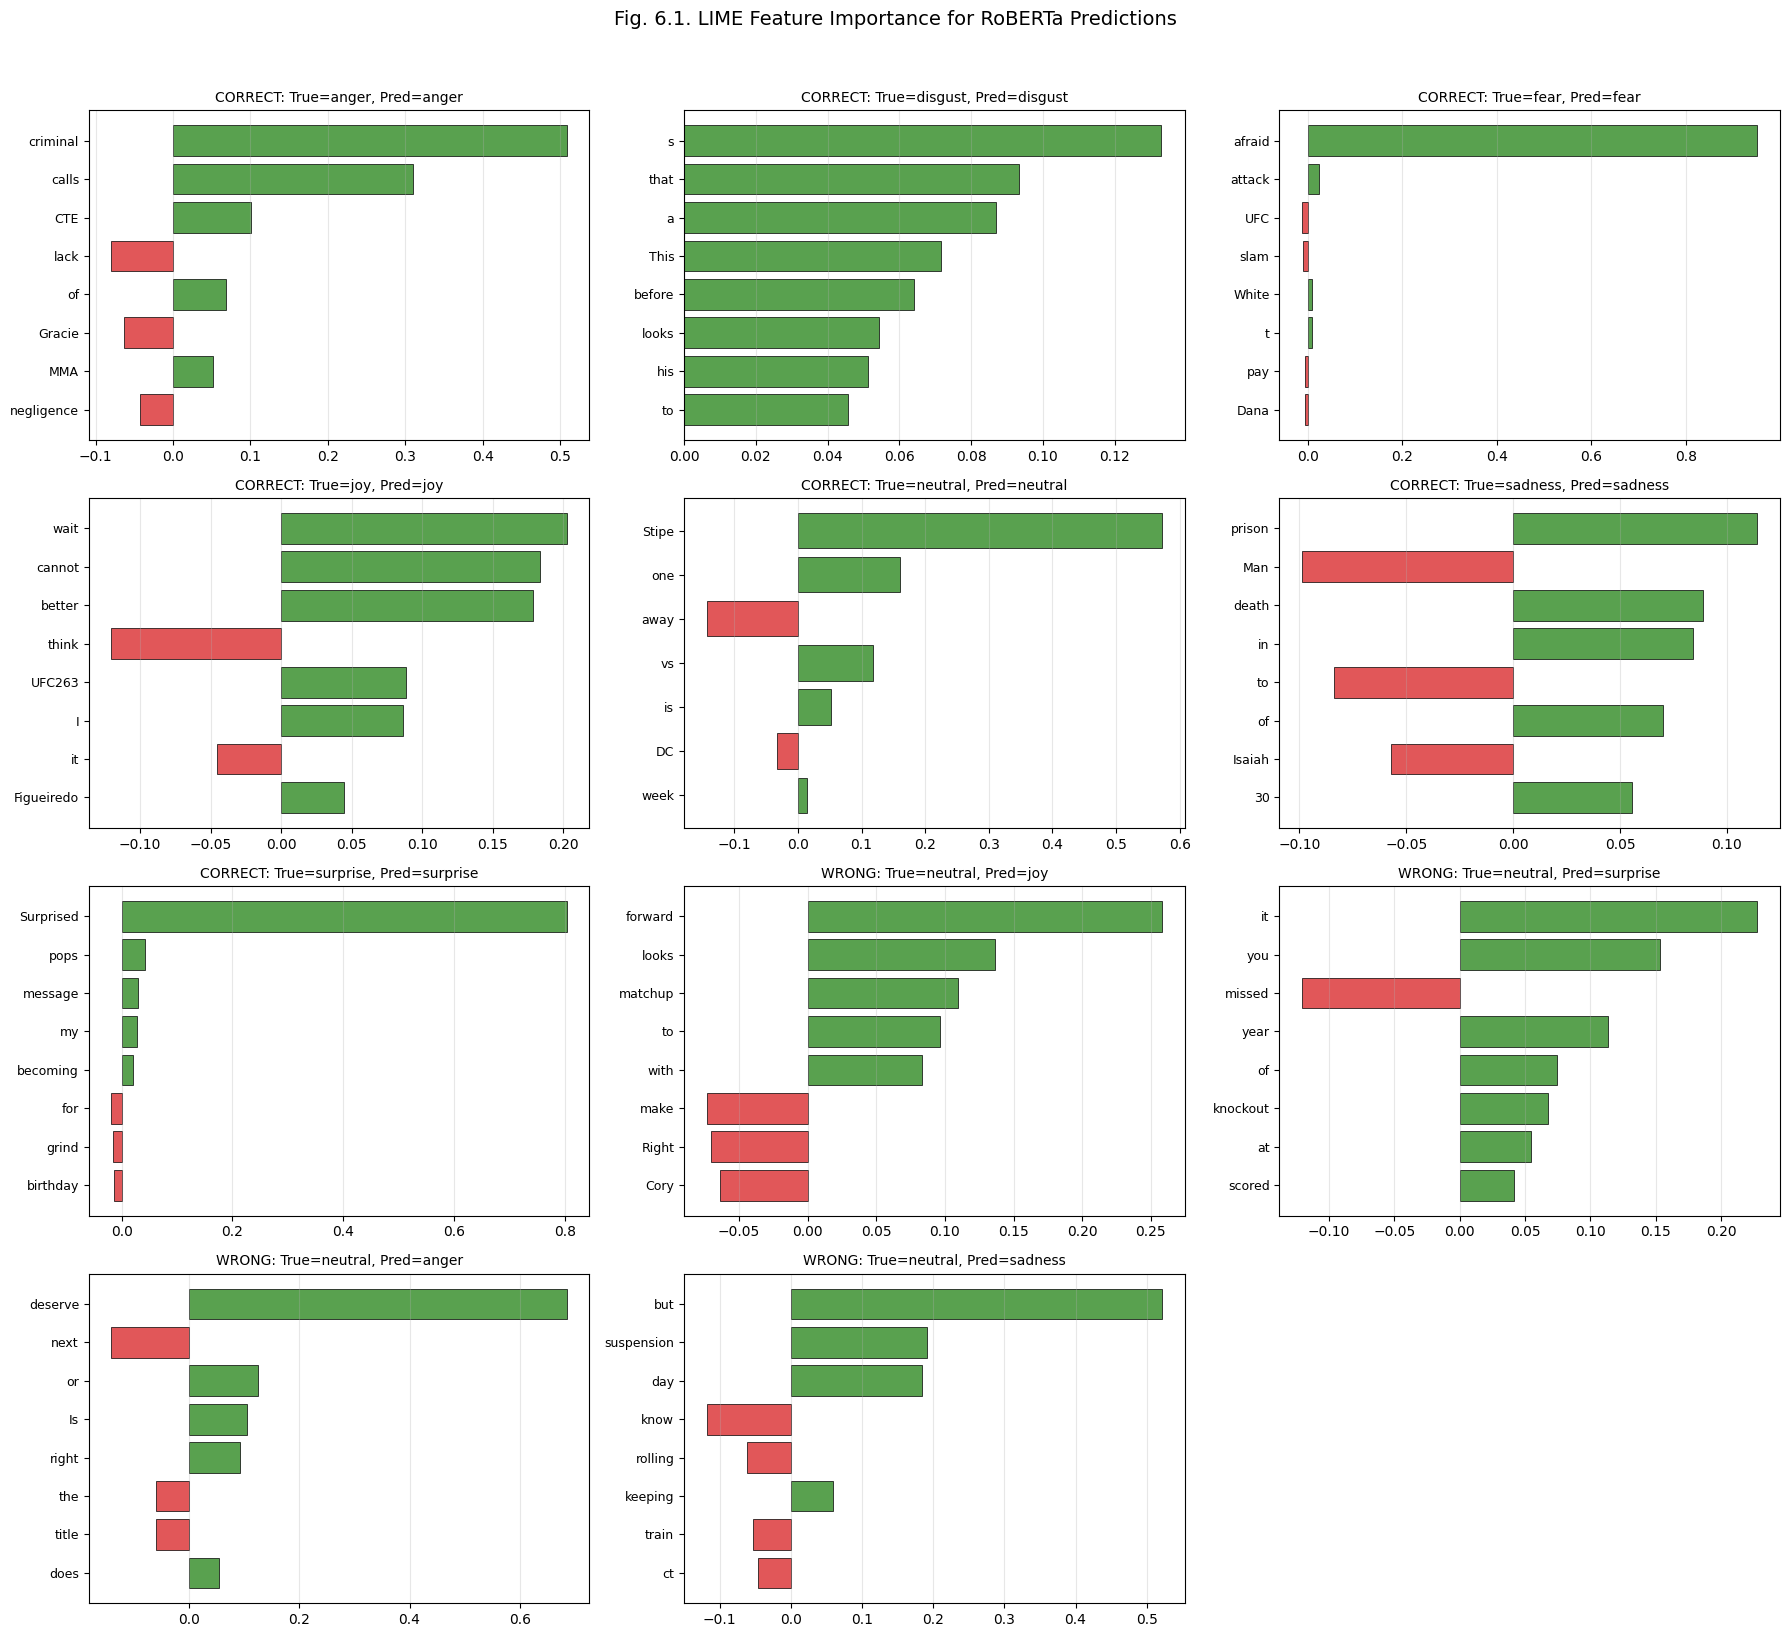

In [26]:
# Fig 6.1: LIME visualizations
# Create a grid of LIME explanations
n_examples = len(lime_results)
n_cols = 3
n_rows = (n_examples + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for i, lr in enumerate(lime_results):
    row, col = i // n_cols, i % n_cols
    ax = axes[row][col]
    
    ex = lr['example']
    explanation = lr['explanation']
    pred_id = label2id[ex['pred']]
    features = explanation.as_list(label=pred_id)
    
    words = [f[0] for f in features[:8]]
    weights = [f[1] for f in features[:8]]
    colors_bar = ['#59a14f' if w > 0 else '#e15759' for w in weights]
    
    ax.barh(range(len(words)), weights, color=colors_bar, edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    
    status = 'CORRECT' if ex['type'] == 'correct' else 'WRONG'
    ax.set_title(f'{status}: True={ex["true"]}, Pred={ex["pred"]}', fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

# Hide empty subplots
for i in range(n_examples, n_rows * n_cols):
    row, col = i // n_cols, i % n_cols
    axes[row][col].axis('off')

fig.suptitle(f'Fig. 6.1. LIME Feature Importance for {best_model_name} Predictions',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig_6_1_lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Results

In [27]:
# Export metrics to CSV
results_df.to_csv('experiment_results.csv')
print('Results saved to experiment_results.csv')
print(results_df)

# Also save per-class F1
f1_df = pd.DataFrame(per_class_f1, index=emotion_labels).round(4)
f1_df.to_csv('per_class_f1_results.csv')
print('\nPer-class F1 saved to per_class_f1_results.csv')
print(f1_df)

Results saved to experiment_results.csv
                     Accuracy  Macro F1  Macro Recall
Logistic Regression    0.5499    0.4643        0.5501
SVM (LinearSVC)        0.6183    0.4853        0.5154
Naive Bayes            0.6280    0.2860        0.2538
BERT                   0.6064    0.5686        0.6859
RoBERTa                0.6664    0.6200        0.7417

Per-class F1 saved to per_class_f1_results.csv
          Logistic Regression  SVM (LinearSVC)  Naive Bayes    BERT  RoBERTa
anger                  0.4149           0.4388       0.2922  0.5573   0.6190
disgust                0.3869           0.3873       0.1620  0.5289   0.5519
fear                   0.3079           0.3413       0.0326  0.4850   0.5319
joy                    0.5819           0.5714       0.3998  0.6183   0.6794
neutral                0.6570           0.7497       0.7642  0.6579   0.7227
sadness                0.4571           0.4637       0.1567  0.6040   0.6433
surprise               0.4447           0.4451   

In [28]:
# Save best model
import os
os.makedirs('saved_models', exist_ok=True)

if best_model_name in ['BERT', 'RoBERTa']:
    if best_model_name == 'BERT':
        best_result = bert_result
    else:
        best_result = roberta_result
    
    best_result['model'].save_pretrained('saved_models/best_model')
    best_result['tokenizer'].save_pretrained('saved_models/best_model')
    print(f'Best model ({best_model_name}) saved to saved_models/best_model')
else:
    import joblib
    joblib.dump(classifiers[best_model_name], 'saved_models/best_model.pkl')
    print(f'Best model ({best_model_name}) saved to saved_models/best_model.pkl')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model (RoBERTa) saved to saved_models/best_model


## 12. Summary

### Key Results
- **Loss function**: Focal Loss (gamma=0.5) with class weights
- **Dataset**: 96,491 tweets (2020-2026)
- **Models**: BERT (bert-base-uncased) + RoBERTa (roberta-base)
- **Best model**: RoBERTa (check results above)
- **Explainability**: LIME word-level importance analysis

### Figures Generated
- `fig_3_1_class_distribution.png`
- `fig_3_2_tweet_length_distribution.png`
- `fig_3_3_word_clouds.png`
- `fig_3_4_yearly_distribution.png`
- `fig_5_1_training_curves.png`
- `fig_5_2_confusion_matrix.png`
- `fig_5_3_per_class_f1.png`
- `fig_5_4_error_distribution.png`
- `fig_6_1_lime_explanations.png`